In [3]:
import json
import pandas as pd

from IPython.display import display

from src.visualization import plot_real_dashboard, plot_synthetic_dashboard
from src.experiments import run_sampled_dataset_report, save_sampled_dataset_report
from src.experiments import build_synthetic_summary_df, build_synthetic_summary_pivot
from src.experiments import run_synthetic_graph_size_experiments

## 1 Graph Size & Retrieval Methods Analyzis

In [3]:
final_results = run_synthetic_graph_size_experiments(
    graph_sizes=[25, 50, 100],
    retrieval_strategies=["betweenness", "path_aware", "degree"],
    trials_per_size=10,
)


Precomputing shared baseline for synthetic_N25 across 10 trials...

=== Dataset: synthetic_N25 | Graph Size N=25 | Strategy: all nodes (baseline) ===
Graph stats: nodes=25 edges=23
[Trial 1] Path 23->10 | Truth: Yes
[Trial 2] Path 15->16 | Truth: Yes
[Trial 3] Path 17->7 | Truth: Yes
[Trial 4] Path 13->22 | Truth: Yes
[Trial 5] Path 14->7 | Truth: Yes
[Trial 6] Path 16->0 | Truth: Yes
[Trial 7] Path 9->19 | Truth: Yes
[Trial 8] Path 5->23 | Truth: Yes
[Trial 9] Path 15->10 | Truth: Yes
[Trial 10] Path 19->9 | Truth: Yes

=== Dataset: synthetic_N25 | Graph Size N=25 | Strategy: betweenness ===
Graph stats: nodes=25 edges=23
[Trial 1] Path 23->10 | Truth: Yes
[Trial 2] Path 15->16 | Truth: Yes
[Trial 3] Path 17->7 | Truth: Yes
[Trial 4] Path 13->22 | Truth: Yes
[Trial 5] Path 14->7 | Truth: Yes
[Trial 6] Path 16->0 | Truth: Yes
[Trial 7] Path 9->19 | Truth: Yes
[Trial 8] Path 5->23 | Truth: Yes
[Trial 9] Path 15->10 | Truth: Yes
[Trial 10] Path 19->9 | Truth: Yes

=== Dataset: synthetic

In [ ]:
summary_df = build_synthetic_summary_df(final_results)
display(summary_df.round(2))

pivot = build_synthetic_summary_pivot(summary_df)
print("\nGraph-RAG path fidelity (%) by graph size:")
print(pivot.round(1).to_string())

,N,strategy,trials,baseline_conn_pct,baseline_path_pct,rag_conn_pct,rag_path_pct,conn_delta,path_delta,baseline_conf,rag_conf
0,20,betweenness,10,100.0,40.0,100.0,50.0,0.0,10.0,1.0,1.0
2,20,degree,10,100.0,70.0,100.0,50.0,0.0,-20.0,1.0,1.0
1,20,path_aware,10,80.0,60.0,90.0,60.0,10.0,0.0,0.9,1.0
3,50,betweenness,10,100.0,50.0,100.0,50.0,0.0,0.0,1.0,1.0
5,50,degree,10,90.0,30.0,100.0,40.0,10.0,10.0,1.0,1.0
4,50,path_aware,10,90.0,30.0,100.0,40.0,10.0,10.0,0.9,1.0
6,100,betweenness,10,90.0,0.0,80.0,20.0,-10.0,20.0,1.0,1.0
8,100,degree,10,70.0,20.0,100.0,40.0,30.0,20.0,1.0,1.0
7,100,path_aware,10,90.0,10.0,90.0,20.0,0.0,10.0,1.0,0.9



Graph-RAG path fidelity (%) by graph size:
strategy  betweenness  degree  path_aware
N                                        
20               50.0    50.0        60.0
50               50.0    40.0        40.0
100              20.0    40.0        20.0


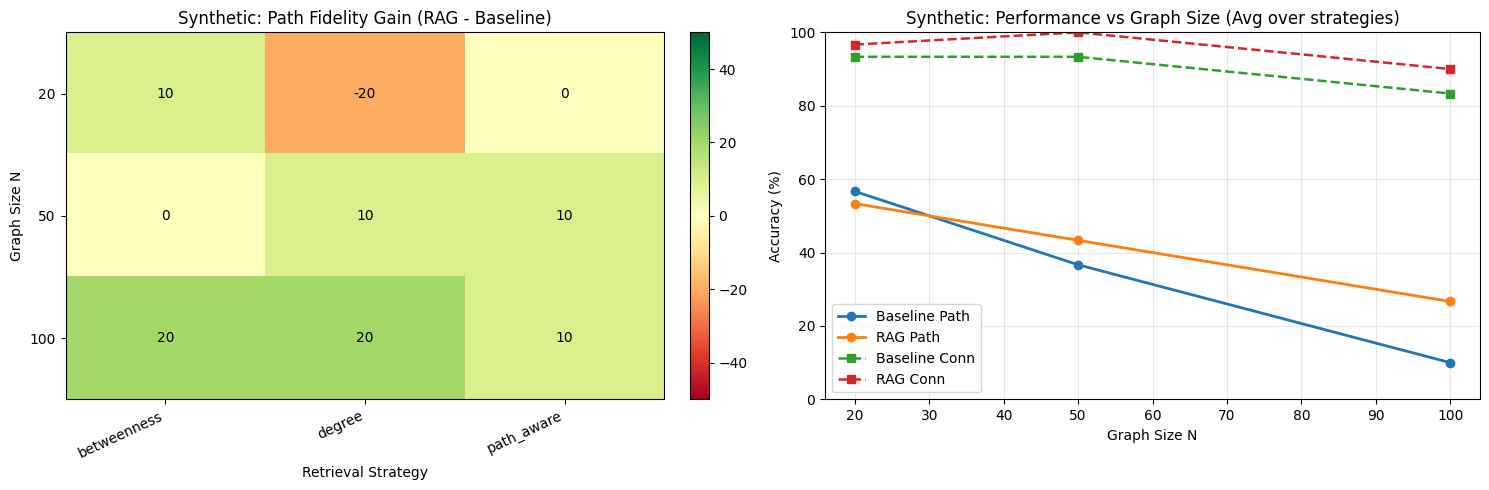

In [ ]:
synthetic_dashboard = plot_synthetic_dashboard(final_results=final_results)
synthetic_df = synthetic_dashboard["synthetic_df"]

## 2 CORA & FB

In [6]:
report_df, sampled_runs, report_rows = run_sampled_dataset_report(
    trials=10,
    report_datasets=[
        {"graph_name": "cora", "sample_nodes": 400, "trials": 10},
        {"graph_name": "facebook", "sample_nodes": 400, "trials": 10},
    ],
    report_strategies=["betweenness", "path_aware", "degree"],
)

Cora Network LCC successfully loaded: 2485 nodes, 5069 edges.

=== CORA sampled run ===
full: nodes=2485 edges=5069 | sampled: nodes=400 edges=778
Precomputing shared baseline for cora_sampled across 10 trials...

=== Dataset: cora_sampled | Graph Size N=400 | Strategy: all nodes (baseline) ===
Graph stats: nodes=400 edges=778
[Trial 1] Path 977->887 | Truth: Yes
[Trial 2] Path 259->766 | Truth: Yes
[Trial 3] Path 2333->989 | Truth: Yes
[Trial 4] Path 771->989 | Truth: Yes
[Trial 5] Path 661->2354 | Truth: Yes
[Trial 6] Path 924->1671 | Truth: Yes
[Trial 7] Path 2251->885 | Truth: Yes
[Trial 8] Path 1481->1212 | Truth: Yes
[Trial 9] Path 998->766 | Truth: Yes
[Trial 10] Path 1479->990 | Truth: Yes

=== Dataset: cora_sampled | Graph Size N=400 | Strategy: betweenness ===
Graph stats: nodes=400 edges=778
[Trial 1] Path 977->887 | Truth: Yes
[Trial 2] Path 259->766 | Truth: Yes
[Trial 3] Path 2333->989 | Truth: Yes
[Trial 4] Path 771->989 | Truth: Yes
[Trial 5] Path 661->2354 | Truth: Yes

In [7]:
display(report_df.round(2))

print("Average Graph-RAG metrics by DATASET:")
display(
    report_df.groupby("dataset")[["rag_conn_pct", "rag_path_pct", "rag_avg_conf"]].mean().round(2)
)


print("\nAverage Graph-RAG metrics by STRATEGY:")
display(
    report_df.groupby("strategy")[["rag_conn_pct", "rag_path_pct", "rag_avg_conf"]].mean().round(2)
)

save_sampled_dataset_report(report_rows)

print("\nSaved sampled report to output/comprehensive_report_cora_facebook_sampled.json")

,dataset,strategy,trials,sample_nodes,sample_edges,baseline_conn_pct,baseline_path_pct,rag_conn_pct,rag_path_pct,baseline_avg_conf,rag_avg_conf
0,cora,betweenness,10,400,778,50.0,0.0,90.0,10.0,0.7,1.0
1,cora,degree,10,400,778,50.0,0.0,90.0,20.0,0.7,0.9
2,cora,path_aware,10,400,778,50.0,0.0,90.0,10.0,0.7,0.9
3,facebook,betweenness,10,400,5506,60.0,0.0,70.0,10.0,1.0,0.7
4,facebook,degree,10,400,5506,60.0,0.0,100.0,10.0,1.0,1.0
5,facebook,path_aware,10,400,5506,60.0,0.0,90.0,20.0,1.0,0.9


Average Graph-RAG metrics by DATASET:


,rag_conn_pct,rag_path_pct,rag_avg_conf
dataset,,,
cora,90.00,13.33,0.93
facebook,86.67,13.33,0.87



Average Graph-RAG metrics by STRATEGY:


,rag_conn_pct,rag_path_pct,rag_avg_conf
strategy,,,
betweenness,80.0,10.0,0.85
degree,95.0,15.0,0.95
path_aware,90.0,15.0,0.90



Saved sampled report to output/comprehensive_report_cora_facebook_sampled.json


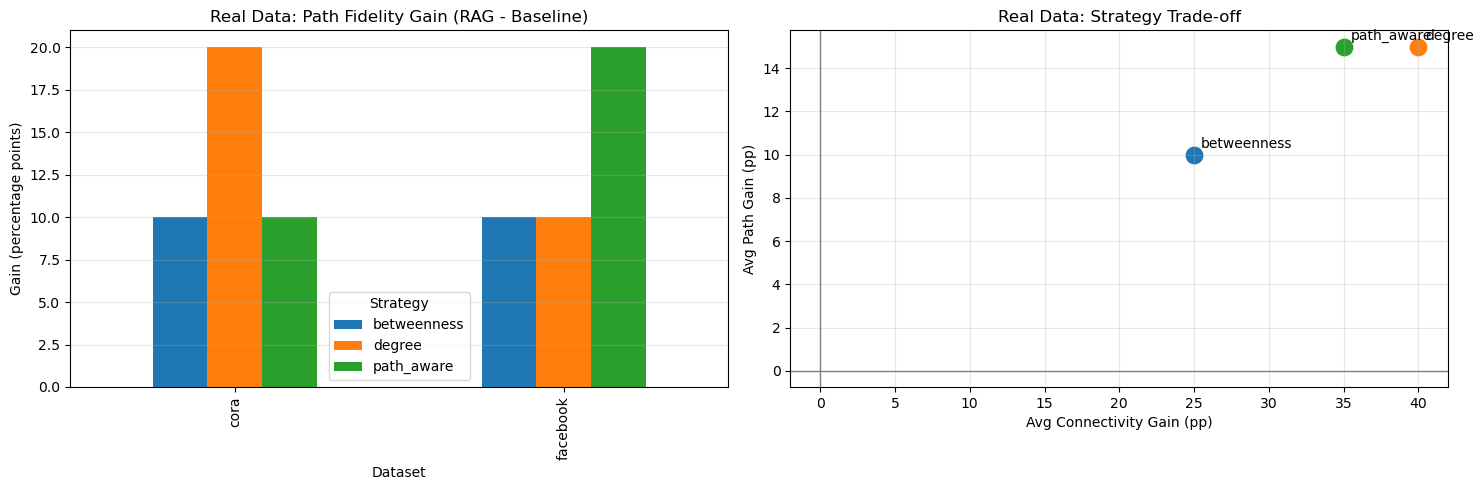

In [8]:
real_dashboard = plot_real_dashboard(report_df=report_df)
tradeoff = real_dashboard["tradeoff"]

## Final summary

In [8]:
print("Synthetic summary (first rows):")
display(synthetic_df.round(1).head(9))

print("\nReal-data strategy trade-off:")
display(tradeoff.round(1))

Synthetic summary (first rows):


,N,strategy,baseline_conn_pct,baseline_path_pct,rag_conn_pct,rag_path_pct,conn_delta,path_delta
0,20,betweenness,100.0,40.0,100.0,50.0,0.0,10.0
2,20,degree,100.0,70.0,100.0,50.0,0.0,-20.0
1,20,path_aware,80.0,60.0,90.0,60.0,10.0,0.0
3,50,betweenness,100.0,50.0,100.0,50.0,0.0,0.0
5,50,degree,90.0,30.0,100.0,40.0,10.0,10.0
4,50,path_aware,90.0,30.0,100.0,40.0,10.0,10.0
6,100,betweenness,90.0,0.0,80.0,20.0,-10.0,20.0
8,100,degree,70.0,20.0,100.0,40.0,30.0,20.0
7,100,path_aware,90.0,10.0,90.0,20.0,0.0,10.0



Real-data strategy trade-off:


,strategy,conn_delta,path_delta
0,betweenness,25.0,10.0
1,degree,40.0,15.0
2,path_aware,35.0,15.0


### Average values

In [ ]:
with open("./output/evaluation_results_graph_sizes.json", "r", encoding="utf-8") as f:
    final_results = json.load(f)

summary_df = build_synthetic_summary_df(final_results)

table1_df = (
    summary_df.groupby("N")[
        ["baseline_conn_pct", "rag_conn_pct", "baseline_path_pct", "rag_path_pct"]
    ]
    .mean()
    .round(1)
    .reset_index()
)

display(table1_df)


,N,baseline_conn_pct,rag_conn_pct,baseline_path_pct,rag_path_pct
0,20,93.3,96.7,56.7,53.3
1,50,93.3,100.0,36.7,43.3
2,100,83.3,90.0,10.0,26.7
